<a href="https://colab.research.google.com/github/luuapriiscila/-Engenharia_de_Prompt_e_Aplicacoes_em_AI-/blob/main/Aula_08_Automacao_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#Aula 08 - Automação com Inteligência
Nome: Luanna Priscila da Silva Tavares



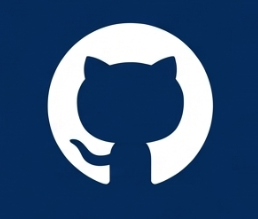


**Dissecando um Script - Verificador de Temperatura**


In [ ]:
# Solicita ao usuário para inserir a temperatura em Celsius
# A função `input()` exibe uma mensagem e espera que o usuário digite algo.
celsius_str = input("Por favor, digite a temperatura atual em Celsius (use vírgula ou ponto para decimais): ")

# Substitui vírgulas por pontos na string de entrada para garantir que `float()` possa converter corretamente números decimais.
# Converte a string resultante para um número de ponto flutuante (float).
celsius = float(celsius_str.replace(',', '.'))

# Calcula a temperatura em Fahrenheit usando a fórmula de conversão.
# Fahrenheit = (Celsius * 1.8) + 32
fahrenheit = celsius * 1.8 + 32

# Inicia uma estrutura condicional `if-else` para verificar a temperatura.
# Se a temperatura em Celsius for maior que 30, o bloco `if` é executado.
if celsius > 30:
    # Exibe um alerta de superaquecimento.
    print("ALERTA: Superaquecimento!")
    # Mostra a temperatura em Celsius.
    print("Temperatura em Celsius:", celsius, "°C")
    # Mostra a temperatura em Fahrenheit.
    print("Temperatura em Fahrenheit:", fahrenheit, "°F")
# Se a temperatura em Celsius não for maior que 30, o bloco `else` é executado.
else:
    # Informa que a temperatura está normal.
    print("Temperatura normal.")
    # Mostra a temperatura em Celsius.
    print("Temperatura em Celsius:", celsius, "°C")
    # Mostra a temperatura em Fahrenheit.
    print("Temperatura em Fahrenheit:", fahrenheit, "°F")

Por favor, digite a temperatura atual em Celsius (use vírgula ou ponto para decimais): 98.09
ALERTA: Superaquecimento!
Temperatura em Celsius: 98.09 °C
Temperatura em Fahrenheit: 208.562 °F


**Missão 01 : Automação de Arquivos**

In [ ]:
# Importa o módulo 'os' para interagir com o sistema operacional, como manipular caminhos de arquivo e diretórios.
import os
# Importa o módulo 'shutil' para operações de alto nível em arquivos e diretórios, como mover arquivos.
import shutil

# Define uma função chamada 'organize_files_by_extension' que recebe o caminho do diretório a ser organizado como argumento.
def organize_files_by_extension(source_directory):
    # Início da docstring que explica o propósito da função.
    """
    Organiza arquivos em um diretório por sua extensão.
    Cria subdiretórios para cada tipo de extensão (ex: PDFs, Imagens, Documentos)
    e move os arquivos para o subdiretório correspondente.
    """
    # Fim da docstring.
    # Verifica se o caminho fornecido não é um diretório existente.
    if not os.path.isdir(source_directory):
        # Exibe uma mensagem de erro se o diretório não existir.
        print(f"Erro: O diretório '{source_directory}' não existe.")
        # Sai da função se o diretório não for válido.
        return

    # Informa ao usuário qual diretório está sendo organizado.
    print(f"Organizando arquivos em: {source_directory}")

    # Dicionário para mapear extensões comuns a nomes de pastas mais amigáveis
    # Cria um dicionário para categorizar extensões de arquivo e mapeá-las para nomes de pastas.
    extension_categories = {
        '.pdf': 'PDFs',
        '.doc': 'Documentos',
        '.docx': 'Documentos',
        '.txt': 'Textos',
        '.csv': 'Dados',
        '.xls': 'Planilhas',
        '.xlsx': 'Planilhas',
        '.ppt': 'Apresentacoes',
        '.pptx': 'Apresentacoes',
        '.jpg': 'Imagens',
        '.jpeg': 'Imagens',
        '.png': 'Imagens',
        '.gif': 'Imagens',
        '.bmp': 'Imagens',
        '.svg': 'Imagens',
        '.mp3': 'Audios',
        '.wav': 'Audios',
        '.mp4': 'Videos',
        '.mov': 'Videos',
        '.avi': 'Videos',
        '.zip': 'Compactados',
        '.rar': 'Compactados',
        '.7z': 'Compactados',
        '.exe': 'Executaveis',
        '.msi': 'Executaveis',
        '.py': 'Scripts_Python',
        '.ipynb': 'Notebooks_Jupyter'
    }

    # Lista todos os itens no diretório
    # Itera sobre cada item (arquivo ou diretório) no diretório de origem.
    for filename in os.listdir(source_directory):
        # Constrói o caminho completo para o item atual.
        file_path = os.path.join(source_directory, filename)

        # Verifica se é um arquivo (e não um diretório)
        # Verifica se o item atual é um arquivo (e não uma pasta).
        if os.path.isfile(file_path):
            # Obtém o nome base do arquivo e a extensão
            # Separa o nome do arquivo da sua extensão.
            name, extension = os.path.splitext(filename)
            # Converte a extensão para minúsculas para padronizar (ex: '.JPG' vira '.jpg').
            extension = extension.lower()

            # Determina o nome da pasta de destino
            # Verifica se a extensão está mapeada no dicionário de categorias.
            if extension in extension_categories:
                # Usa o nome de pasta amigável definido no dicionário.
                destination_folder_name = extension_categories[extension]
            # Se a extensão não estiver no dicionário, mas o arquivo tem uma extensão.
            elif extension:
                # Se a extensão não estiver no dicionário, usa a própria extensão como nome da pasta
                # Cria o nome da pasta a partir da extensão (ex: 'TXT_Files').
                destination_folder_name = extension[1:].upper() + '_Files'
            # Para arquivos que não possuem extensão.
            else:
                # Para arquivos sem extensão
                # Coloca arquivos sem extensão em uma pasta 'Outros'.
                destination_folder_name = 'Outros'

            # Constrói o caminho completo para a pasta de destino.
            destination_path = os.path.join(source_directory, destination_folder_name)

            # Cria a pasta de destino se ela não existir
            # Verifica se a pasta de destino não existe.
            if not os.path.exists(destination_path):
                # Cria a pasta de destino se ela não existir.
                os.makedirs(destination_path)
                # Informa que uma nova pasta foi criada.
                print(f"Pasta criada: {destination_path}")

            # Move o arquivo para a pasta de destino
            # Inicia um bloco try-except para lidar com possíveis erros durante a movimentação.
            try:
                # Move o arquivo para a pasta de destino.
                shutil.move(file_path, os.path.join(destination_path, filename))
                # Informa que o arquivo foi movido.
                print(f"Movido: {filename} -> {destination_folder_name}/")
            # Captura erros específicos do módulo shutil (ex: arquivo já existe no destino).
            except shutil.Error as e:
                # Exibe a mensagem de erro específica do shutil.
                print(f"Erro ao mover {filename}: {e}")
            # Captura qualquer outro erro inesperado.
            except Exception as e:
                # Exibe a mensagem de erro inesperado.
                print(f"Ocorreu um erro inesperado ao mover {filename}: {e}")

    # Informa que a organização foi concluída.
    print("\nOrganização concluída!")

# --- Como usar o programa ---
# 1. Defina o caminho para o diretório que você quer organizar.
#    Por exemplo, se seus arquivos estiverem na mesma pasta do notebook, use '.'
#    Ou use um caminho absoluto: '/content/meus_arquivos_baguncados'

# Exemplo de uso:
# Coloque o caminho do diretório que você quer organizar aqui.
# Para testar, você pode criar alguns arquivos de exemplo usando os comandos 'touch'
# !touch 'meu_documento.pdf' 'minha_imagem.jpg' 'nota.txt' 'video.mp4'

# Define o diretório a ser organizado. '.' significa o diretório atual do notebook.
source_dir_to_organize = './'

# Bloco de demonstração: Cria arquivos, organiza e mostra o resultado
print("--------------------------------------------------")
print("Demonstração: Criando e organizando arquivos de exemplo")
print("--------------------------------------------------")

# Lista de arquivos de exemplo a serem criados
example_files = [
    'relatorio_final.pdf',
    'foto_ferias.jpg',
    'anotacoes.txt',
    'dados_vendas.csv',
    'video_aula.mp4',
    'documentos_antigos.zip'
]

print("Criando arquivos de exemplo:")
for filename in example_files:
    # Cria cada arquivo de exemplo usando o comando 'touch'
    os.system(f"touch '{filename}'")
    print(f"  - Criado: {filename}")

print("\nIniciando a organização dos arquivos...")
# Chama a função para iniciar o processo de organização de arquivos.
organize_files_by_extension(source_dir_to_organize)

print("\n--------------------------------------------------")
print("Estrutura final dos diretórios:")
print("--------------------------------------------------")
# Exibe a estrutura de diretórios para mostrar a organização
# O comando `ls -R` lista o conteúdo dos diretórios recursivamente.
os.system('ls -R')

--------------------------------------------------
Demonstração: Criando e organizando arquivos de exemplo
--------------------------------------------------
Criando arquivos de exemplo:
  - Criado: relatorio_final.pdf
  - Criado: foto_ferias.jpg
  - Criado: anotacoes.txt
  - Criado: dados_vendas.csv
  - Criado: video_aula.mp4
  - Criado: documentos_antigos.zip

Iniciando a organização dos arquivos...
Organizando arquivos em: ./
Pasta criada: ./PDFs
Movido: relatorio_final.pdf -> PDFs/
Pasta criada: ./Dados
Movido: dados_vendas.csv -> Dados/
Pasta criada: ./Imagens
Movido: foto_ferias.jpg -> Imagens/
Pasta criada: ./Videos
Movido: video_aula.mp4 -> Videos/
Pasta criada: ./Textos
Movido: anotacoes.txt -> Textos/
Pasta criada: ./Compactados
Movido: documentos_antigos.zip -> Compactados/

Organização concluída!

--------------------------------------------------
Estrutura final dos diretórios:
--------------------------------------------------


0

**Missão 02 - Consulta Simples a APIs**

In [ ]:
# Importa a biblioteca 'requests' para fazer requisições HTTP a APIs.
import requests

# Define a função 'consultar_cep' que recebe um CEP como argumento.
def consultar_cep(cep):
    # Constrói a URL da API ViaCEP com o CEP fornecido. O f-string permite formatar a string com variáveis.
    url = f"https://viacep.com.br/ws/{cep}/json/"

    # Inicia um bloco 'try' para lidar com possíveis exceções durante a requisição.
    try:
        # Faz a requisição GET para a URL da API e armazena a resposta.
        response = requests.get(url)
        # Levanta uma exceção HTTPError para respostas de status de erro (4xx ou 5xx).
        response.raise_for_status()

        # Converte a resposta JSON em um dicionário Python.
        data = response.json()

        # Verifica se a resposta da API indica um erro (CEP não encontrado).
        if "erro" in data and data["erro"]:
            # Retorna uma mensagem de erro específica para CEP não encontrado.
            return "CEP não encontrado."
        else:
            # Retorna os dados do endereço se o CEP for válido.
            return data

    # Captura exceções específicas de conexão, como problemas de rede ou DNS.
    except requests.exceptions.ConnectionError:
        # Retorna uma mensagem de erro para problemas de conexão.
        return "Erro de conexão: Verifique sua internet."
    # Captura exceções para timeouts de requisição.
    except requests.exceptions.Timeout:
        # Retorna uma mensagem de erro para requisições que excederam o tempo limite.
        return "A requisição excedeu o tempo limite."
    # Captura outras exceções relacionadas a requisições HTTP (erros 4xx/5xx).
    except requests.exceptions.RequestException as e:
        # Retorna uma mensagem de erro geral para problemas na requisição.
        return f"Erro na requisição: {e}"
    # Captura exceções se a resposta não puder ser decodificada como JSON.
    except ValueError:
        # Retorna uma mensagem de erro para JSON inválido.
        return "Erro ao decodificar a resposta JSON."

# Bloco principal para execução do script.
if __name__ == "__main__":
    # Solicita ao usuário para digitar um CEP.
    cep_digitado = input("Digite o CEP (apenas números): ")

    # Remove qualquer caractere não numérico do CEP digitado para garantir a formatação correta.
    cep_limpo = ''.join(filter(str.isdigit, cep_digitado))

    # Verifica se o CEP limpo tem 8 dígitos, que é o formato padrão do ViaCEP.
    if len(cep_limpo) == 8:
        # Chama a função 'consultar_cep' com o CEP limpo.
        endereco = consultar_cep(cep_limpo)

        # Verifica se o resultado da consulta é um dicionário (indicando sucesso).
        if isinstance(endereco, dict):
            # Imprime o endereço formatado de maneira legível.
            print("\n--- Endereço Encontrado ---")
            # Imprime o CEP.
            print(f"CEP: {endereco.get('cep')}")
            # Imprime o logradouro.
            print(f"Logradouro: {endereco.get('logradouro')}")
            # Imprime o complemento.
            print(f"Complemento: {endereco.get('complemento')}")
            # Imprime o bairro.
            print(f"Bairro: {endereco.get('bairro')}")
            # Imprime a cidade.
            print(f"Cidade: {endereco.get('localidade')}")
            # Imprime o estado (UF).
            print(f"Estado: {endereco.get('uf')}")
            # Imprime o DDD.
            print(f"DDD: {endereco.get('ddd')}")
            print("---------------------------")
        else:
            # Se não for um dicionário, significa que houve um erro e imprime a mensagem de erro.
            print(f"\nErro: {endereco}")
    else:
        # Informa ao usuário se o CEP digitado não tem o formato correto.
        print("\nErro: O CEP deve conter exatamente 8 dígitos numéricos.")

Digite o CEP (apenas números): 73751063

--- Endereço Encontrado ---
CEP: 73751-063
Logradouro: Quadra 4 MR 4
Complemento: 
Bairro: Setor Norte
Cidade: Planaltina
Estado: GO
DDD: 61
---------------------------


**Missão 3 - Sistema de Notificações**

In [1]:
# Importa o módulo `datetime` para trabalhar com objetos de data e hora.
import datetime
# Importa o módulo `time` para adicionar pausas na execução do programa (simulação de tempo).
import time

# --- Classe para o Sistema de Notificações ---
# Define a classe `NotificationSystem`, que será responsável por enviar alertas.
class NotificationSystem:
    # Define o método `send_alert` dentro da classe `NotificationSystem`.
    # Este método recebe `self` (referência à própria instância) e `message` (a mensagem do alerta).
    def send_alert(self, message):
        # Docstring: Uma breve descrição da funcionalidade do método.
        """Simula o envio de um alerta para o console."""
        # Obtém a data e hora atuais e formata-as como uma string no formato 'AAAA-MM-DD HH:MM:SS'.
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        # Imprime a mensagem de alerta no console, prefixada com '[ALERTA - timestamp]'.
        print(f"\n[ALERTA - {timestamp}] {message}")

# --- Classe para a Empresa de Investimentos ---
# Define a classe `InvestmentCompany`, que representa a empresa no sistema.
class InvestmentCompany:
    # O método `__init__` é o construtor da classe, chamado ao criar uma nova instância.
    # Ele recebe `self` e `weekly_target` (a meta de lucro semanal).
    def __init__(self, weekly_target):
        # Armazena a meta semanal de lucro no atributo `self.weekly_target`.
        self.weekly_target = weekly_target
        # Inicializa o lucro atual da empresa como 0.0.
        self.current_profit = 0.0
        # Inicializa um sinalizador booleano para indicar se a meta semanal foi atingida, começando como `False`.
        self.weekly_target_met = False
        # Cria uma instância de `NotificationSystem` para que a empresa possa enviar seus próprios alertas.
        self.notification_system = NotificationSystem()

    # Define o método `update_profit` para atualizar o lucro da empresa.
    # Ele recebe `self` e `amount` (a quantidade de lucro a ser adicionada).
    def update_profit(self, amount):
        # Docstring: Descreve o que o método faz.
        """Atualiza o lucro atual e verifica se a meta semanal foi atingida."""
        # Adiciona o `amount` recebido ao `self.current_profit`.
        self.current_profit += amount
        # Imprime o lucro atual e a meta semanal, formatando os valores monetários.
        print(f"Lucro atualizado: R${self.current_profit:.2f}. Meta semanal: R${self.weekly_target:.2f}")
        # Verifica se o lucro atual (`self.current_profit`) atingiu ou ultrapassou a meta semanal (`self.weekly_target`)
        # E se a meta ainda não foi alertada (`not self.weekly_target_met`).
        if self.current_profit >= self.weekly_target and not self.weekly_target_met:
            # Se a condição for verdadeira, dispara um alerta informando que a meta semanal foi atingida.
            self.notification_system.send_alert("META SEMANAL ATINGIDA! Parabéns equipe!")
            # Define o sinalizador `self.weekly_target_met` como `True` para evitar alertas repetidos para a mesma meta.
            self.weekly_target_met = True

# --- Classe para o Funcionário ---
# Define a classe `Employee`, que representa um funcionário.
class Employee:
    # O método `__init__` é o construtor da classe `Employee`.
    # Ele recebe `self` e `name` (o nome do funcionário).
    def __init__(self, name):
        # Armazena o nome do funcionário no atributo `self.name`.
        self.name = name
        # Inicializa um sinalizador booleano para indicar se o funcionário está na empresa, começando como `False`.
        self.is_at_work = False
        # Inicializa o horário de início do turno como `None`.
        self.shift_started = None
        # Inicializa o horário de término do turno como `None`.
        # Cria uma instância de `NotificationSystem` para que o funcionário possa enviar seus próprios alertas.
        self.notification_system = NotificationSystem()

    # Define o método `enter_company` para simular a entrada do funcionário na empresa.
    def enter_company(self):
        # Docstring: Descreve o que o método faz.
        """Simula a entrada do funcionário na empresa e dispara um alerta."""
        # Verifica se o funcionário NÃO está atualmente na empresa.
        if not self.is_at_work:
            # Se não estiver, define `self.is_at_work` como `True`.
            self.is_at_work = True
            # Registra o horário atual como o início do turno.
            self.shift_started = datetime.datetime.now()
            # Dispara um alerta informando a entrada do funcionário e o horário de início do turno.
            self.notification_system.send_alert(f"{self.name} entrou na empresa. Início do turno: {self.shift_started.strftime('%H:%M')}")
        else:
            # Se o funcionário já estiver na empresa, imprime uma mensagem informativa.
            print(f"{self.name} já está na empresa.")

    # Define o método `leave_company` para simular a saída do funcionário da empresa.
    def leave_company(self):
        # Docstring: Descreve o que o método faz.
        """Simula a saída do funcionário da empresa e dispara um alerta."""
        # Verifica se o funcionário ESTÁ atualmente na empresa.
        if self.is_at_work:
            # Se estiver, define `self.is_at_work` como `False`.
            self.is_at_work = False
            # Registra o horário atual como o fim do turno.
            self.shift_ended = datetime.datetime.now()
            # Dispara um alerta informando a saída do funcionário e o horário de término do turno.
            self.notification_system.send_alert(f"{self.name} terminou seu turno e saiu da empresa. Fim do turno: {self.shift_ended.strftime('%H:%M')}")
        else:
            # Se o funcionário não estiver na empresa, imprime uma mensagem informativa.
            print(f"{self.name} não está na empresa para sair.")

# --- Simulação do Sistema ---
# Este bloco de código garante que as instruções abaixo só serão executadas quando o script for rodado diretamente.
if __name__ == "__main__":
    # Imprime uma mensagem para indicar o início da simulação.
    print("### Iniciando Simulação do Sistema de Notificações ###")

    # 1. Configuração inicial
    # Cria uma instância da `InvestmentCompany` com uma meta semanal de R$ 50.000,00.
    company = InvestmentCompany(weekly_target=50000.00)
    # Cria uma instância do `Employee` para 'Luanna Priscila'.
    employee1 = Employee("Luanna Priscila")
    # Cria uma instância do `Employee` para 'João Silva'.
    employee2 = Employee("João Silva")

    # Imprime uma mensagem para indicar o início do dia de trabalho.
    print("\n--- Dia de Trabalho Começa ---")

    # 2. Funcionário entra na empresa (Alarme 3)
    # Chama o método `enter_company` para o `employee1`, disparando o alerta de entrada.
    employee1.enter_company()
    # Chama o método `enter_company` para o `employee2`, disparando o alerta de entrada.
    employee2.enter_company()
    # Pausa a execução por 1 segundo para simular a passagem do tempo.
    time.sleep(1)

    # 3. Empresa gerando lucro
    # Imprime uma mensagem para indicar que a empresa está gerando lucro.
    print("\n--- Empresa gerando lucro ---")
    # Atualiza o lucro da empresa com R$ 15.000,00.
    company.update_profit(15000.00)
    # Pausa a execução por 1 segundo.
    time.sleep(1)
    # Atualiza o lucro da empresa com mais R$ 20.000,00.
    company.update_profit(20000.00)
    # Pausa a execução por 1 segundo.
    time.sleep(1)

    # 4. Atingindo a meta semanal (Alarme 1)
    # Imprime uma mensagem para indicar a verificação da meta.
    print("\n--- Checando meta ---")
    # Atualiza o lucro da empresa com mais R$ 16.000,00. Isso fará com que o lucro total ultrapasse a meta (15k + 20k + 16k = 51k),
    # disparando o alerta de META SEMANAL ATINGIDA (Alarme 1).
    company.update_profit(16000.00)
    # Pausa a execução por 1 segundo.
    time.sleep(1)
    # Atualiza o lucro da empresa com mais R$ 5.000,00. Embora o lucro aumente, o alerta da meta já foi disparado e não será repetido.
    company.update_profit(5000.00)
    # Pausa a execução por 1 segundo.
    time.sleep(1)

    # 5. Funcionário termina o turno (Alarme 2)
    # Imprime uma mensagem para indicar o fim do expediente.
    print("\n--- Fim do expediente ---")
    # Chama o método `leave_company` para o `employee1`, disparando o alerta de saída do turno.
    employee1.leave_company()
    # Pausa a execução por 1 segundo.
    time.sleep(1)
    # Chama o método `leave_company` para o `employee2`, disparando o alerta de saída do turno.
    employee2.leave_company()

    # Imprime uma mensagem para indicar que a simulação foi concluída.
    print("\n### Simulação Concluída ###")

### Iniciando Simulação do Sistema de Notificações ###

--- Dia de Trabalho Começa ---

[ALERTA - 2026-04-15 20:58:13] Luanna Priscila entrou na empresa. Início do turno: 20:58

[ALERTA - 2026-04-15 20:58:13] João Silva entrou na empresa. Início do turno: 20:58

--- Empresa gerando lucro ---
Lucro atualizado: R$15000.00. Meta semanal: R$50000.00
Lucro atualizado: R$35000.00. Meta semanal: R$50000.00

--- Checando meta ---
Lucro atualizado: R$51000.00. Meta semanal: R$50000.00

[ALERTA - 2026-04-15 20:58:16] META SEMANAL ATINGIDA! Parabéns equipe!
Lucro atualizado: R$56000.00. Meta semanal: R$50000.00

--- Fim do expediente ---

[ALERTA - 2026-04-15 20:58:18] Luanna Priscila terminou seu turno e saiu da empresa. Fim do turno: 20:58

[ALERTA - 2026-04-15 20:58:19] João Silva terminou seu turno e saiu da empresa. Fim do turno: 20:58

### Simulação Concluída ###


**Documentação**

Os prompts ajudaram a dar um guiamento lógico para a AI, pois sem eles poderíamos ter sim códigos que funcionam, mas sem utilidade alguma. E prompts bem estruturados, ajudam a chegarmos a um objetivo de maneira objetiva e mais centrado na realização do objetivo, e o fato de escrevermos o prompt da refatoração ajudou bastante a identificar o funcionamento de cada parte que constitui o script.

**Reflexão**

Bom, eu compreendi que a AI usada como um assistente de programação, eleva o nível da produtividade ao agilizar na automação, mas é esse o ponto crítico, ao ter a atitude de deixar a AI fazer tudo sozinha sem dar o mínimo de estrutura no seu prompt, ela vai gerar coisas alucinosas, então precisa ter a consciência que o engenheiro de prompt é tão essencial do que a escolha de alguma AI ,pois ele vai dar o direcionamento, a tarefa a ser feita, a meta a ser atingida. Logo para uma assistente precisa de um superior competente para guiar as tarefas.